# MASpecFormer Downstream Redshift Regression Task (mini demo)

This notebook demonstrates how to load a trained MASpecFormer model, read an H5 dataset, extract embeddings, and use simple pooling + MLP to predict redshift. Suitable for sanity check/quick validation.

In [1]:
# 1. Environment and Dependency Loading
import os
import torch
import lightning as L
import numpy as np
import h5py
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from tqdm.auto import tqdm

# Import MASpecFormer data module
from encoder_spectrum.ma_specformer.data.datamodule import MASpectrumDataModule
from encoder_spectrum.ma_specformer.data.dataset import MASpectrumDataset

# Set random seed and thread count
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(2)


/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


In [2]:
# 2. Path Configuration and Device Check
# Modify paths as needed
ckpt_path = '/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/log/ma_specformer_single_gpu/version_1/checkpoints/last.ckpt'
cfg_path = '/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/log/ma_specformer_single_gpu/version_1/config.yaml'
h5_path = '/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5'  # or f115w.h5

# Check CUDA
use_cuda = torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')
print(f'Using device: {device}')


Using device: cuda


In [3]:
# 3. Load Trained MASpecFormer (weight compatibility & strict handling)
import yaml
from encoder_spectrum.ma_specformer.model.ma_specformer import MASpecFormer

# Load config
with open(cfg_path, 'r') as f:
    config = yaml.safe_load(f)
model_args = config['model']

# Instantiate model from config
model = MASpecFormer(**model_args)
model = model.to(device)

# Load checkpoint
ckpt = torch.load(ckpt_path, map_location=device)
state_dict = ckpt['state_dict'] if 'state_dict' in ckpt else ckpt

# Remove possible prefix (e.g., 'model.')
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('model.'):
        new_state_dict[k[len('model.'):]] = v
    else:
        new_state_dict[k] = v

missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

model.eval()



Missing keys: []
Unexpected keys: []


MASpecFormer(
  (token_embed): Linear(in_features=3, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): SelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ln2): LayerNorm()
      (mlp): MLP(
        (fc1): Linear(in_features=64, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (final_ln): LayerNorm()
  (head): Linear(in_features=64, out_features=1, bias=True)
)

In [4]:
# 4. Load Small Portion of Data (1200 samples: 1000 train + 100 eval + 100 test)
h5_path = '/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5'  # or f115w.h5

# Load only 1200 samples from dataset
datamodule = MASpectrumDataModule(
    h5_path=h5_path,
    batch_size=32,
    num_workers=2,
    train_val_split=0.8,  # This will be for full dataset, but we'll subsample
)

datamodule.setup()

# Get full dataset and subsample to 1200
total_dataset = datamodule.dataset
n_samples = 12000  # Small subset: 1000 train + 100 eval + 100 test

# Create indices for subset
subset_indices = np.random.RandomState(42).choice(len(total_dataset), size=min(n_samples, len(total_dataset)), replace=False)
from torch.utils.data import Subset
subset_dataset = Subset(total_dataset, subset_indices)

print(f"Full dataset size: {len(total_dataset)}")
print(f"Subset size: {len(subset_dataset)}")

# Manually split: 1000 train, 100 eval, 100 test
train_indices = subset_indices[:5000]
eval_indices = subset_indices[4500:4800]
test_indices = subset_indices[4800:5000]

train_dataset = Subset(total_dataset, train_indices)
eval_dataset = Subset(total_dataset, eval_indices)
test_dataset = Subset(total_dataset, test_indices)

# Create dataloaders (train_loader shuffle=False to maintain order with embeddings)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train set: {len(train_dataset)} samples")
print(f"Eval set: {len(eval_dataset)} samples")
print(f"Test set: {len(test_dataset)} samples")

# Check a sample
sample = total_dataset[0]
print(f"\nSample flux shape: {sample['flux'].shape}")
print(f"Flux stats: min={sample['flux'].min():.3f}, max={sample['flux'].max():.3f}")
print(f"Flux has nan: {torch.isnan(sample['flux']).any()}, has inf: {torch.isinf(sample['flux']).any()}")


Full dataset size: 30199
Subset size: 12000
Train set: 5000 samples
Eval set: 300 samples
Test set: 200 samples

Sample flux shape: torch.Size([99])
Flux stats: min=-0.072, max=0.000
Flux has nan: False, has inf: False


In [5]:
# 5. Forward Embedding Computation from train_loader (only 10000 samples)
# Now directly use model.encode() which handles normalization internally
embeddings_train = []
embeddings_eval = []
embeddings_test = []

model.eval()

print("Computing embeddings from train set...")
with torch.no_grad():
    for batch_idx, batch in enumerate(train_loader):
        flux = batch['flux'].to(device)
        wavelength = batch['wavelength'].to(device)
        valid_mask = batch['valid_mask'].to(device)
        
        # Directly call encode() - normalization happens automatically inside
        emb = model.encode(flux, wavelength, valid_mask)
        embeddings_train.append(emb.detach().cpu())

embeddings_train = torch.cat(embeddings_train, dim=0)
print(f'Train embeddings shape: {embeddings_train.shape}')

print("Computing embeddings from eval set...")
with torch.no_grad():
    for batch in tqdm(eval_loader):
        flux = batch['flux'].to(device)
        wavelength = batch['wavelength'].to(device)
        valid_mask = batch['valid_mask'].to(device)
        
        # Directly call encode() - normalization happens automatically inside
        emb = model.encode(flux, wavelength, valid_mask)
        embeddings_eval.append(emb.detach().cpu())

embeddings_eval = torch.cat(embeddings_eval, dim=0)
print(f'Eval embeddings shape: {embeddings_eval.shape}')

print("Computing embeddings from test set...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        flux = batch['flux'].to(device)
        wavelength = batch['wavelength'].to(device)
        valid_mask = batch['valid_mask'].to(device)
        
        # Directly call encode() - normalization happens automatically inside
        emb = model.encode(flux, wavelength, valid_mask)
        embeddings_test.append(emb.detach().cpu())

embeddings_test = torch.cat(embeddings_test, dim=0)
print(f'Test embeddings shape: {embeddings_test.shape}')
print(f'All embeddings have nan/inf: {torch.isnan(embeddings_train).any() or torch.isinf(embeddings_train).any()}')

Computing embeddings from train set...
Train embeddings shape: torch.Size([5000, 99, 64])
Computing embeddings from eval set...
Eval embeddings shape: torch.Size([300, 99, 64])
Computing embeddings from test set...


  0%|          | 0/7 [00:00<?, ?it/s]

Test embeddings shape: torch.Size([200, 99, 64])
All embeddings have nan/inf: False


In [6]:
# 6. Pool Embeddings and Prepare Datasets (train / eval / test)
def pool_embeddings(embeddings, dataset, indices):
    """Pool embeddings over valid positions for given indices."""
    pool_emb = []
    for idx in tqdm(indices):
        sample = dataset[idx]
        valid_mask = sample['valid_mask'].numpy()
        emb = embeddings[indices.tolist().index(idx)].numpy()  # Get corresponding embedding
        
        if valid_mask.sum() == 0:
            pool_emb.append(emb.mean(axis=0))
        else:
            pool_emb.append(emb[valid_mask].mean(axis=0))
    
    return np.stack(pool_emb, axis=0)

# Read redshifts for all three sets
def read_redshifts(h5_path, indices):
    """Read redshifts from H5 file for given indices."""
    redshifts = []
    with h5py.File(h5_path, 'r') as f:
        for idx in indices:
            redshifts.append(f['redshift'][idx])
    return np.array(redshifts)

print("Pooling embeddings...")
pool_train = pool_embeddings(embeddings_train, total_dataset, train_indices)
pool_eval = pool_embeddings(embeddings_eval, total_dataset, eval_indices)
pool_test = pool_embeddings(embeddings_test, total_dataset, test_indices)

print(f"Pooled train shape: {pool_train.shape}")
print(f"Pooled eval shape: {pool_eval.shape}")
print(f"Pooled test shape: {pool_test.shape}")

# Read redshifts
print("Reading redshifts...")
redshift_train = torch.tensor(read_redshifts(h5_path, train_indices), dtype=torch.float32).view(-1, 1)
redshift_eval = torch.tensor(read_redshifts(h5_path, eval_indices), dtype=torch.float32).view(-1, 1)
redshift_test = torch.tensor(read_redshifts(h5_path, test_indices), dtype=torch.float32).view(-1, 1)

print(f"Train redshifts: {redshift_train.shape}")
print(f"Eval redshifts: {redshift_eval.shape}")
print(f"Test redshifts: {redshift_test.shape}")

# Create TensorDatasets
pool_train = torch.tensor(pool_train, dtype=torch.float32)
pool_eval = torch.tensor(pool_eval, dtype=torch.float32)
pool_test = torch.tensor(pool_test, dtype=torch.float32)

dataset_train = TensorDataset(pool_train, redshift_train)
dataset_eval = TensorDataset(pool_eval, redshift_eval)
dataset_test = TensorDataset(pool_test, redshift_test)

# Create dataloaders for downstream regression
train_loader_regress = DataLoader(dataset_train, batch_size=32, shuffle=True)
eval_loader_regress = DataLoader(dataset_eval, batch_size=32, shuffle=False)
test_loader_regress = DataLoader(dataset_test, batch_size=32, shuffle=False)

print(f"\nDownstream task setup:")
print(f"  Train: {len(dataset_train)} samples (batch size 32)")
print(f"  Eval: {len(dataset_eval)} samples (batch size 32)")
print(f"  Test: {len(dataset_test)} samples (batch size 32)")


Pooling embeddings...
Pooled train shape: (5000, 64)
Pooled eval shape: (300, 64)
Pooled test shape: (200, 64)
Reading redshifts...
Train redshifts: torch.Size([5000, 1])
Eval redshifts: torch.Size([300, 1])
Test redshifts: torch.Size([200, 1])

Downstream task setup:
  Train: 5000 samples (batch size 32)
  Eval: 300 samples (batch size 32)
  Test: 200 samples (batch size 32)


In [11]:
# 7. Define Simple MLP Regression Head
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,8),
            nn.ReLU(),
            nn.Linear(8,1)
        )
    def forward(self, x):
        return self.mlp(x)

mlp = MLP(pool_train.shape[1], hidden=64).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

print(f"MLP created with input dim: {pool_train.shape[1]}")


MLP created with input dim: 64


Starting redshift regression training...
Training on 5000 samples, validating on 300 samples

Epoch   2: train_loss=1.310983, eval_loss=1.305769
Epoch   4: train_loss=1.306522, eval_loss=1.279945
Epoch   6: train_loss=1.305354, eval_loss=1.264756
Epoch   8: train_loss=1.309252, eval_loss=1.297508
Epoch  10: train_loss=1.311329, eval_loss=1.303716
Epoch  12: train_loss=1.305671, eval_loss=1.292653
Epoch  14: train_loss=1.312517, eval_loss=1.274254
Epoch  16: train_loss=1.303178, eval_loss=1.274652
Epoch  18: train_loss=1.311813, eval_loss=1.289149
Epoch  20: train_loss=1.308120, eval_loss=1.252325
Epoch  22: train_loss=1.305896, eval_loss=1.265579
Epoch  24: train_loss=1.308716, eval_loss=1.286953
Epoch  26: train_loss=1.301872, eval_loss=1.260344
Epoch  28: train_loss=1.309287, eval_loss=1.287071
Epoch  30: train_loss=1.302757, eval_loss=1.274462
Epoch  32: train_loss=1.305570, eval_loss=1.258751
Epoch  34: train_loss=1.304815, eval_loss=1.307671
Epoch  36: train_loss=1.300249, eval_lo

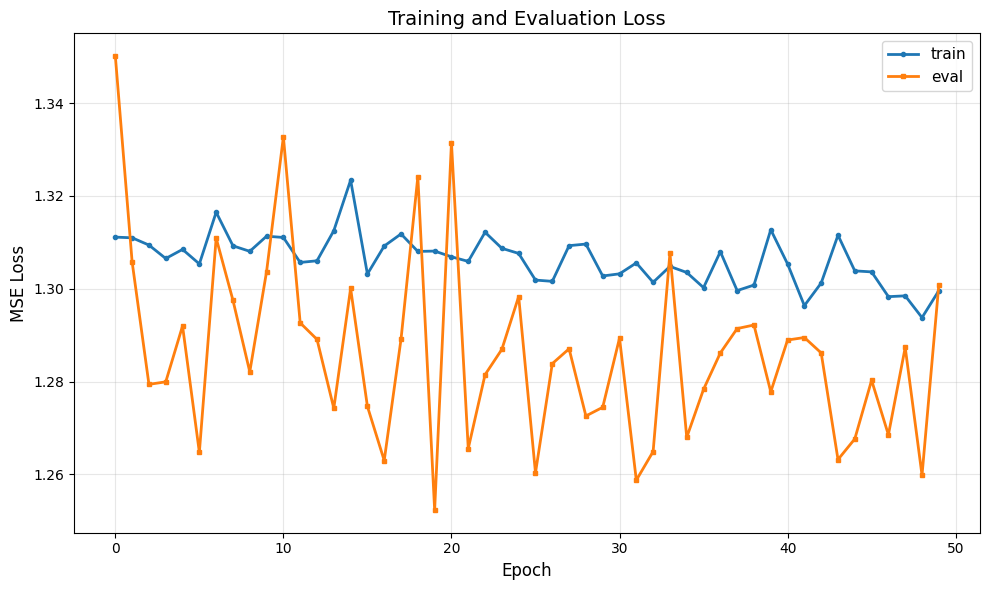

In [13]:
# 8. Training Loop on Train Set (1000 samples)
num_epochs = 50
train_losses, eval_losses = [], []

print("Starting redshift regression training...")
print(f"Training on {len(dataset_train)} samples, validating on {len(dataset_eval)} samples\n")

for epoch in range(num_epochs):
    mlp.train()
    train_loss = 0
    for x, y in train_loader_regress:
        x, y = x.to(device), y.to(device)
        pred = mlp(x)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    
    train_loss /= len(dataset_train)
    train_losses.append(train_loss)
    
    # Evaluation on eval set
    mlp.eval()
    eval_loss = 0
    with torch.no_grad():
        for x, y in eval_loader_regress:
            x, y = x.to(device), y.to(device)
            pred = mlp(x)
            loss = loss_fn(pred, y)
            eval_loss += loss.item() * x.size(0)
    
    eval_loss /= len(dataset_eval)
    eval_losses.append(eval_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1:3d}: train_loss={train_loss:.6f}, eval_loss={eval_loss:.6f}")

print("\nTraining complete!")

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='train', linewidth=2, marker='o', markersize=3)
plt.plot(eval_losses, label='eval', linewidth=2, marker='s', markersize=3)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.title('Training and Evaluation Loss', fontsize=14)
plt.tight_layout()
plt.show()


Evaluating on eval set (100 samples)...
=== Eval Set Results (100 samples) ===
MAE: 0.891848
RMSE: 1.140565
R²: 0.0127


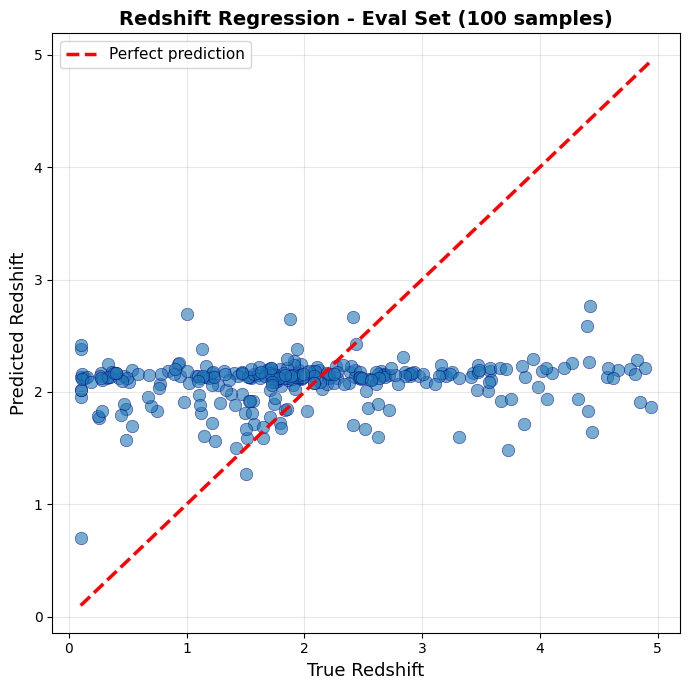

In [14]:
# 9. Evaluation on Eval Set (100 samples)
mlp.eval()
eval_preds, eval_trues = [], []

print("Evaluating on eval set (100 samples)...")
with torch.no_grad():
    for x, y in eval_loader_regress:
        x = x.to(device)
        pred = mlp(x).cpu().numpy()
        eval_preds.append(pred)
        eval_trues.append(y.numpy())

eval_preds = np.concatenate(eval_preds, axis=0).flatten()
eval_trues = np.concatenate(eval_trues, axis=0).flatten()

eval_mae = np.mean(np.abs(eval_preds - eval_trues))
eval_rmse = np.sqrt(np.mean((eval_preds - eval_trues) ** 2))
eval_r2 = 1 - (np.sum((eval_preds - eval_trues) ** 2) / np.sum((eval_trues - eval_trues.mean()) ** 2))

print(f'=== Eval Set Results (100 samples) ===')
print(f'MAE: {eval_mae:.6f}')
print(f'RMSE: {eval_rmse:.6f}')
print(f'R²: {eval_r2:.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(eval_trues, eval_preds, alpha=0.6, s=80, edgecolors='navy', linewidth=0.5)
ax.plot([eval_trues.min(), eval_trues.max()], [eval_trues.min(), eval_trues.max()], 
        'r--', linewidth=2.5, label='Perfect prediction')
ax.set_xlabel('True Redshift', fontsize=13)
ax.set_ylabel('Predicted Redshift', fontsize=13)
ax.set_title('Redshift Regression - Eval Set (100 samples)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 10. Model Loading & Common Troubleshooting

- If model weights fail to load, print `ckpt['state_dict'].keys()` and compare with model parameter names. Strip prefixes like `model.`, `net.` if needed.
- Check device consistency: all tensors/models should be on the same device.
- If dimensions mismatch, print shapes and use `.view()` or `.unsqueeze()` to adjust.
- If the `redshift` field is missing, use another field or mock data for testing.
- If embedding dimension or pooling/MLP mismatch, check pooling code and model config.

Refer to this cell for debug tips if you encounter issues.

Evaluating on test set (100 samples)...

=== Test Set Results (100 samples) ===
MAE: 0.964903
RMSE: 1.170177
R²: 0.0369


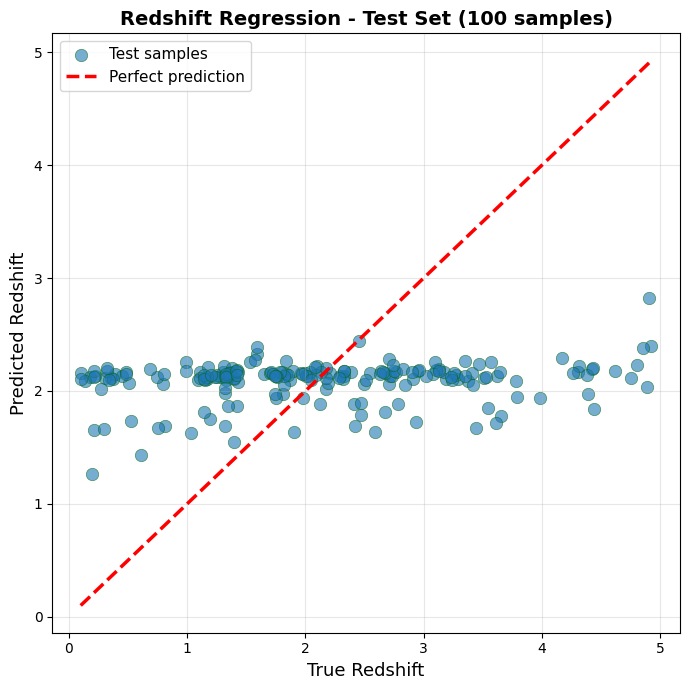


=== Final Summary ===
Train set:  1000 samples (for optimization)
Eval set:   100 samples  (for hyperparameter tuning)
Test set:   100 samples  (for final evaluation)

Eval  - MAE: 0.891848, RMSE: 1.140565, R²: 0.0127
Test  - MAE: 0.964903, RMSE: 1.170177, R²: 0.0369


In [15]:
# 11. Test Set Evaluation (100 samples - completely held out)
mlp.eval()
test_preds, test_trues = [], []

print("Evaluating on test set (100 samples)...")
with torch.no_grad():
    for x, y in test_loader_regress:
        x = x.to(device)
        pred = mlp(x).cpu().numpy()
        test_preds.append(pred)
        test_trues.append(y.numpy())

test_preds = np.concatenate(test_preds, axis=0).flatten()
test_trues = np.concatenate(test_trues, axis=0).flatten()

test_mae = np.mean(np.abs(test_preds - test_trues))
test_rmse = np.sqrt(np.mean((test_preds - test_trues) ** 2))
test_r2 = 1 - (np.sum((test_preds - test_trues) ** 2) / np.sum((test_trues - test_trues.mean()) ** 2))

print(f'\n=== Test Set Results (100 samples) ===')
print(f'MAE: {test_mae:.6f}')
print(f'RMSE: {test_rmse:.6f}')
print(f'R²: {test_r2:.4f}')

# Visualization
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(test_trues, test_preds, alpha=0.6, s=80, edgecolors='darkgreen', linewidth=0.5, label='Test samples')
ax.plot([test_trues.min(), test_trues.max()], [test_trues.min(), test_trues.max()], 
        'r--', linewidth=2.5, label='Perfect prediction')
ax.set_xlabel('True Redshift', fontsize=13)
ax.set_ylabel('Predicted Redshift', fontsize=13)
ax.set_title('Redshift Regression - Test Set (100 samples)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print(f'\n=== Final Summary ===')
print(f'Train set:  1000 samples (for optimization)')
print(f'Eval set:   100 samples  (for hyperparameter tuning)')
print(f'Test set:   100 samples  (for final evaluation)')
print(f'\nEval  - MAE: {eval_mae:.6f}, RMSE: {eval_rmse:.6f}, R²: {eval_r2:.4f}')
print(f'Test  - MAE: {test_mae:.6f}, RMSE: {test_rmse:.6f}, R²: {test_r2:.4f}')
